In [8]:
pip install xgboost

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
df = pd.read_csv("heart_disease.csv")
print(df.head())


   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   67    0   1       155   176    0        0      185      0     0.76      2   
1   57    0   3       129   304    1        1      115      0     1.77      0   
2   43    1   2       113   337    0        0       99      1     1.86      2   
3   71    1   1       141   174    0        1      175      0     0.40      1   
4   36    0   0        91   255    0        1      107      0     2.90      2   

   ca  thal  target  
0   4     1       1  
1   2     1       1  
2   1     1       1  
3   0     0       1  
4   1     0       0  


In [11]:
# Check nulls
print(df.isnull().sum())

# Features & target
X = df.drop("target", axis=1)
y = df["target"]

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [12]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=200, random_state=42)

In [13]:
y_pred = model.predict(X_test)

In [14]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9527777777777777

Confusion Matrix:
[[2645  279]
 [ 146 5930]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93      2924
           1       0.96      0.98      0.97      6076

    accuracy                           0.95      9000
   macro avg       0.95      0.94      0.95      9000
weighted avg       0.95      0.95      0.95      9000



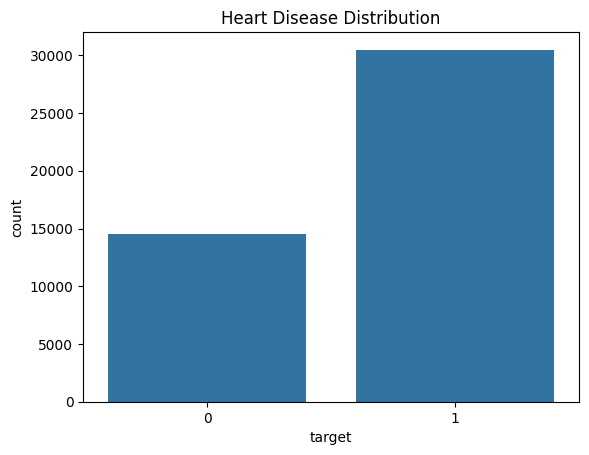

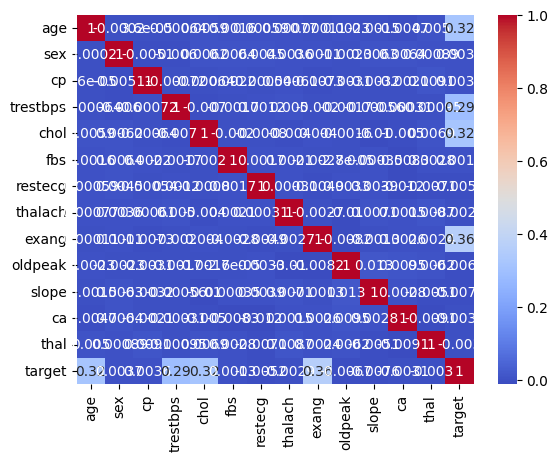

In [15]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [16]:
# Install if needed
# pip install xgboost

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss')

params = {
    'n_estimators': [200, 300],
    'max_depth': [5, 7, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1]
}

grid = GridSearchCV(model, params, cv=3, scoring='accuracy')
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Best Accuracy:", accuracy_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:30:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:30:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:30:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:31:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

Best Accuracy: 0.9527777777777777


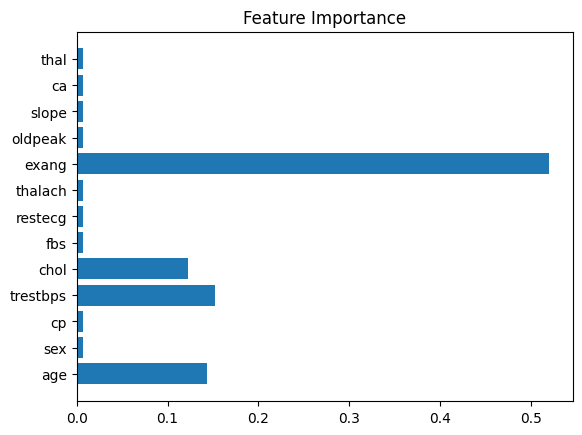

In [17]:
import matplotlib.pyplot as plt

importance = best_model.feature_importances_
features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()